In [ ]:
import netCDF4
import numpy as np
import pandas as pd
import geopandas as gpd
from datetime import datetime, timedelta
from tqdm import tqdm
from shapely.geometry import Point
from scipy.stats import skew, kurtosis, entropy
from scipy.fft import fft
from sklearn.preprocessing import MinMaxScaler
import os
#from pycaret.classification import setup, compare_models, tune_model, finalize_model, save_model, plot_model, evaluate_model, dashboard, save_experiment, blend_models, get_config
import pyarrow as pa
import pyarrow.parquet as pq
from sklearn.model_selection import train_test_split
from numpy import full
import scipy as sp
import numpy as np
from scipy import stats

from joblib import Parallel, delayed
import warnings
warnings.filterwarnings('ignore')

In [2]:
ROOT_DIR =  "./sample_data/" #E:/data/RONGOWAI_L1_SDR_V1.0/' # Change this to your root directory

In [3]:
class SurfaceTypeUtils:
    surface_type_dict = {
        -1: "Ocean",
        0: "NaN",
        1: "Artifical",
        2: "Barely vegetated",
        3: "Inland water",
        4: "Crop",
        5: "Grass",
        6: "Shrub",
        7: "Forest"
    }
    ddm_antennas = {
        0: 'None',
        1: 'Zenith',
        2: 'LHCP',
        3: 'RHCP',
    }

In [4]:
class GeoUtils:
    def __init__(self, world_shapefile_path):
        self.world = gpd.read_file(world_shapefile_path)

    @staticmethod
    def add_seconds(time, seconds):
        timestamp = datetime.strptime(time, "%Y-%m-%d %H:%M:%S")
        new_timestamp = timestamp + timedelta(seconds=seconds)
        return new_timestamp.strftime("%Y-%m-%d %H:%M:%S")

    def is_land(self, lat, lon):
        point = Point(lon, lat)
        return any(self.world.contains(point))

    @staticmethod
    def check_ocean_and_land(lst):
        has_ocean = -1 in lst
        has_land = any(1 <= num <= 7 for num in lst)
        return has_ocean and has_land

    @staticmethod
    def fill_and_filter(arr):
        mask_all_nan = np.all(np.isnan(arr), axis=(2, 3))
        arr_filled = arr.copy()
        for i in range(arr.shape[0]):
            nan_indices = np.where(mask_all_nan[i])[0]
            if len(nan_indices) > 0:
                valid_indices = np.where(~mask_all_nan[i])[0]
                if len(valid_indices) > 0:
                    mean_matrix = np.nanmean(arr[i, valid_indices, :, :], axis=0)
                    arr_filled[i, nan_indices, :, :] = mean_matrix
        mask_discard = np.all(mask_all_nan, axis=1)
        arr_filtered = arr_filled[~mask_discard]
        return arr_filtered, list(np.where(mask_discard.astype(int) == 1)[0])


In [ ]:
class NetCDFPreprocessor:
    def __init__(self, root_dir, preprocessing_method=str):
        self.root_dir = root_dir
        self.netcdf_file_list = os.listdir(root_dir)
        self.preprocessing_method = preprocessing_method
        if self.preprocessing_method not in ['filtered', 'with_lat_lons', 'unfiltered']:
            raise ValueError("Invalid preprocessing method. Choose from 'filtered', 'with_lat_lons', or 'unfiltered'.")

    @staticmethod
    def check_integrity(f):
        """Check integrity of the netCDF file"""
        if not isinstance(f, netCDF4.Dataset):
            raise ValueError("Input must be a netCDF4.Dataset object")
        if 'raw_counts' not in f.variables:
            raise KeyError("The netCDF file does not contain 'raw_counts' variable")
        if 'sp_alt' not in f.variables or 'sp_inc_angle' not in f.variables:
            raise KeyError("The netCDF file does not contain 'sp_alt' or 'sp_inc_angle' variables")
        if 'sp_rx_gain_copol' not in f.variables or 'sp_rx_gain_xpol' not in f.variables or 'ddm_snr' not in f.variables:
            raise KeyError("The netCDF file does not contain 'sp_rx_gain_copol', 'sp_rx_gain_xpol' or 'ddm_snr' variables")
        if 'sp_lat' not in f.variables or 'sp_lon' not in f.variables:
            raise KeyError("The netCDF file does not contain 'sp_lat' or 'sp_lon' variables")
        if 'sp_surface_type' not in f.variables:
            raise KeyError("The netCDF file does not contain 'sp_surface_type' variable")
        if 'ac_alt' not in f.variables:
            raise KeyError("The netCDF file does not contain 'ac_alt' variable")
        if f.variables['raw_counts'].ndim != 4:
            raise ValueError("The 'raw_counts' variable must have 4 dimensions")

    def preprocess_snr_filtered(self, f):
        """ Preprocess the netCDF file and return fit data, labels and specular point centers with filtering on signal-to-noise ratio """
        # Check integrity of the netCDF file
        self.check_integrity(f)

        raw_counts = f.variables['raw_counts'][:]
        ac_alt = f.variables['ac_alt'][:]
        sp_alt = f.variables['sp_alt'][:]
        copol = f.variables['sp_rx_gain_copol'][:]
        xpol = f.variables['sp_rx_gain_xpol'][:]
        snr = f.variables['ddm_snr'][:]
        sp_inc_angle = f.variables['sp_inc_angle'][:]
        sp_center_bin_delay_row = f.variables['brcs_ddm_peak_bin_delay_row'][:]
        sp_center_bin_delay_col = f.variables['brcs_ddm_peak_bin_dopp_col'][:]

        distance_2d = (ac_alt[:, np.newaxis] - sp_alt) / np.cos(np.deg2rad(sp_inc_angle)) # Distance between the aircraft and the specular point

        # Filtering mask
        keep_mask = (
            (copol >= 5) & # # SP copolarized gain
            (xpol >= 5) & # SP cross-polarized gain
            (snr > 0) & # Positive signal-to-Noise Ratio
            (distance_2d >= 2000) & #SP distance min
            (distance_2d <= 10000) & #SP distance max
            ~np.isnan(copol) & 
            ~np.isnan(xpol) & 
            ~np.isnan(snr) & 
            ~np.isnan(distance_2d)
        )

        aux_row_counts = np.full(raw_counts.shape, np.nan, dtype=np.float32)
        aux_array_sp_row = np.full(sp_center_bin_delay_row.shape, np.nan, dtype=np.float32)
        aux_array_sp_col = np.full(sp_center_bin_delay_col.shape, np.nan, dtype=np.float32)
        
        i_indices, j_indices = np.where(keep_mask)
        aux_row_counts[i_indices, j_indices] = raw_counts[i_indices, j_indices]
        aux_array_sp_row[i_indices, j_indices] = sp_center_bin_delay_row[i_indices, j_indices]
        aux_array_sp_col[i_indices, j_indices] = sp_center_bin_delay_col[i_indices, j_indices]

        assert aux_row_counts.shape[0] == aux_array_sp_row.shape[0] , "First dimension mismatch among aux_row_counts and aux_array_sp_row arrays"
        assert aux_row_counts.shape[0] == aux_array_sp_col.shape[0] , "First dimension mismatch among aux_row_counts and aux_array_sp_col arrays"

        n_time, n_samples = raw_counts.shape[:2]
        aux_raw_counts_reshaped = aux_row_counts.reshape(n_time * n_samples, *raw_counts.shape[2:])
        aux_array_sp_row_reshaped = aux_array_sp_row.reshape(n_time * n_samples, *aux_array_sp_row.shape[2:])
        aux_array_sp_col_reshaped = aux_array_sp_col.reshape(n_time * n_samples, *aux_array_sp_col.shape[2:])

        assert aux_raw_counts_reshaped.shape[0] == aux_array_sp_row_reshaped.shape[0], "First dimension mismatch among aux_raw_counts_reshaped and aux_array_sp_row_reshaped arrays after reshaping"
        assert aux_raw_counts_reshaped.shape[0] == aux_array_sp_col_reshaped.shape[0], "First dimension mismatch among aux_raw_counts_reshaped and aux_array_sp_col_reshaped arrays after reshaping"
        #freeing memory
        del aux_row_counts
        del aux_array_sp_row
        del aux_array_sp_col

        # Filter out NaN and zero-sum rows
        valid_mask = ~np.any(np.isnan(aux_raw_counts_reshaped), axis=(1, 2)) & (np.sum(aux_raw_counts_reshaped, axis=(1, 2)) > 0)

        sp_center_bin_delay_row_filtered = aux_array_sp_row_reshaped[valid_mask]
        sp_center_bin_delay_col_filtered = aux_array_sp_col_reshaped[valid_mask]
        sp_centers_filtered = list(zip(sp_center_bin_delay_row_filtered.flatten(), sp_center_bin_delay_col_filtered.flatten()))

        fit_data = aux_raw_counts_reshaped[valid_mask].reshape(valid_mask.sum(), -1)

        assert len(sp_centers_filtered) == fit_data.shape[0], "First dimension sp_centers_filtered and fit_data mismatch after reshaping"


        surface_types = np.nan_to_num(f.variables["sp_surface_type"][:], nan=0).ravel()
        label_data = np.isin(surface_types, np.arange(1, 8)).astype(np.int32)
        label_data = label_data[valid_mask]
        
        # Ensure that fit_data and label_data have the same length
        assert fit_data.shape[0] == len(label_data), \
            f"Shape mismatch: fit_data {fit_data.shape[0]}, label_data {len(label_data)}"

        assert len(sp_centers_filtered) == fit_data.shape[0], "First dimension sp_centers_filtered and fit_data mismatch after reshaping"

        return fit_data, label_data, sp_centers_filtered

    """def preprocess_w_lat_lons(self, f):
        # Version of the preprocessing function returning latitude and longitudes of the specular points

        self.check_integrity(f)
        raw_counts = np.array(f.variables['raw_counts'])

        # Distance between the aircraft and the specular point
        ac_alt_2d = np.repeat(np.array(f.variables['ac_alt'])[:, np.newaxis], 20, axis=1)
        distance_2d = (ac_alt_2d - f.variables['sp_alt'][:]) / np.cos(np.deg2rad(f.variables['sp_inc_angle'][:]))

        copol = f.variables['sp_rx_gain_copol'][:]
        xpol = f.variables['sp_rx_gain_xpol'][:]
        snr = f.variables['ddm_snr'][:]
        dist = distance_2d[:]
        specular_point_lat = f.variables['sp_lat'][:]
        specular_point_lon = f.variables['sp_lon'][:]

        # Filtering with mask
        keep_mask = (copol >= 5) & (xpol >= 5) & (snr > 0) & ((dist >= 2000) & (dist <= 10000)) & (~np.isnan(copol.data) & ~np.isnan(xpol.data) & ~np.isnan(snr.data) & ~np.isnan(dist.data) & ~np.isnan(specular_point_lat.data) & ~np.isnan(specular_point_lon.data))
        to_keep_indices = np.argwhere(keep_mask)

        filtered_raw_counts = [raw_counts[i, j] for i, j in to_keep_indices]
        aux_row_counts = np.full(raw_counts.shape, np.nan, dtype=np.float32)

        specular_point_lats = specular_point_lat[to_keep_indices[:, 0]]
        specular_point_lons = specular_point_lon[to_keep_indices[:, 0]]

        for idx, (i, j) in enumerate(to_keep_indices):
            aux_row_counts[i, j] = filtered_raw_counts[idx]
        # Reshape the output array to match the original dimensions
            raw_counts_filtered = aux_row_counts.copy()

        raw_counts_filtered = aux_row_counts.copy()
        del aux_row_counts

        ddm_data_dict = {
            'Raw_Counts': raw_counts_filtered.reshape(raw_counts_filtered.shape[0]*raw_counts_filtered.shape[1], raw_counts_filtered.shape[2], raw_counts_filtered.shape[3]),
        }
        keep_indices = np.where(
            np.all(~np.isnan(ddm_data_dict['Raw_Counts']), axis=(1, 2)) & (np.sum(ddm_data_dict['Raw_Counts'], axis=(1, 2)) > 0)
        )[0]
        fit_data = np.array([ddm_data_dict['Raw_Counts'][f].ravel() for f in keep_indices])

        specular_point_lats = specular_point_lat.ravel()[keep_indices]
        specular_point_lons = specular_point_lon.ravel()[keep_indices]

        surface_types = f.variables["sp_surface_type"][:]
        surface_types = np.nan_to_num(surface_types, nan=0)
        surface_types_unravelled = surface_types.ravel()
        label_data = [1 if surface_type in np.arange(1, 8) else 0 for surface_type in surface_types_unravelled]
        label_data = [label_data[lab] for lab in range(len(label_data)) if lab in keep_indices]

        assert np.array(fit_data).shape[0] == len(label_data) == np.array(specular_point_lats).shape[0] == np.array(specular_point_lons).shape[0], \
            f"Shape mismatch: fit_data {np.array(fit_data).shape[0]}, label_data {len(label_data)}, lats {np.array(specular_point_lats).shape[0]}, lons {np.array(specular_point_lons).shape[0]}"


        return fit_data, label_data, specular_point_lats, specular_point_lons"""

    def preprocess_snr_unfiltered(self, f):
        """ Preprocess the netCDF file and return fit data, labels and specular point centers without filtering on signal-to-noise ratio """
        # Check integrity of the netCDF file
        self.check_integrity(f)

        raw_counts = f.variables['raw_counts'][:]
        ac_alt = f.variables['ac_alt'][:]
        sp_alt = f.variables['sp_alt'][:]
        sp_inc_angle = f.variables['sp_inc_angle'][:]
        copol = f.variables['sp_rx_gain_copol'][:]
        xpol = f.variables['sp_rx_gain_xpol'][:]
        #snr = f.variables['ddm_snr'][:]
        sp_center_bin_delay_row = f.variables['brcs_ddm_peak_bin_delay_row'][:]
        sp_center_bin_delay_col = f.variables['brcs_ddm_peak_bin_dopp_col'][:]

        #Distance between the aircraft and the specular point
        distance_2d = (ac_alt[:, np.newaxis] - sp_alt) / np.cos(np.deg2rad(sp_inc_angle))
        # Filtering mask without SNR
        keep_mask = (
            (copol >= 5) & 
            (xpol >= 5) & 
        #   (snr > 0)  &
            (distance_2d >= 2000) & 
            (distance_2d <= 10000) &
            ~np.isnan(copol) & 
            ~np.isnan(xpol) & 
            #~np.isnan(snr) & 
            ~np.isnan(distance_2d)
        )
    
        aux_row_counts = np.full(raw_counts.shape, np.nan, dtype=np.float32)
        aux_array_sp_row = np.full(sp_center_bin_delay_row.shape, np.nan, dtype=np.float32)
        aux_array_sp_col = np.full(sp_center_bin_delay_col.shape, np.nan, dtype=np.float32)

        i_indices, j_indices = np.where(keep_mask)

        aux_row_counts[i_indices, j_indices] = raw_counts[i_indices, j_indices]
        aux_array_sp_row[i_indices, j_indices] = sp_center_bin_delay_row[i_indices, j_indices]
        aux_array_sp_col[i_indices, j_indices] = sp_center_bin_delay_col[i_indices, j_indices]

        assert aux_row_counts.shape[0] == aux_array_sp_row.shape[0] , "First dimension mismatch among aux_row_counts and aux_array_sp_row arrays"
        assert aux_row_counts.shape[0] == aux_array_sp_col.shape[0] , "First dimension mismatch among aux_row_counts and aux_array_sp_col arrays"

        n_time, n_samples = raw_counts.shape[:2]
        aux_raw_counts_reshaped = aux_row_counts.reshape(n_time * n_samples, *raw_counts.shape[2:])
        aux_array_sp_row_reshaped = aux_array_sp_row.reshape(n_time * n_samples, *aux_array_sp_row.shape[2:])
        aux_array_sp_col_reshaped = aux_array_sp_col.reshape(n_time * n_samples, *aux_array_sp_col.shape[2:])


        assert aux_raw_counts_reshaped.shape[0] == aux_array_sp_row_reshaped.shape[0], "First dimension mismatch among aux_raw_counts_reshaped and aux_array_sp_row_reshaped arrays after reshaping"
        assert aux_raw_counts_reshaped.shape[0] == aux_array_sp_col_reshaped.shape[0], "First dimension mismatch among aux_raw_counts_reshaped and aux_array_sp_col_reshaped arrays after reshaping"

        del aux_row_counts
        del aux_array_sp_row
        del aux_array_sp_col

        valid_mask = ~np.any(np.isnan(aux_raw_counts_reshaped), axis=(1, 2)) & (np.sum(aux_raw_counts_reshaped, axis=(1, 2)) > 0)

        sp_center_bin_delay_row_filtered = aux_array_sp_row_reshaped[valid_mask]
        sp_center_bin_delay_col_filtered = aux_array_sp_col_reshaped[valid_mask]
        sp_centers_filtered = list(zip(sp_center_bin_delay_row_filtered.flatten(), sp_center_bin_delay_col_filtered.flatten()))

        fit_data = aux_raw_counts_reshaped[valid_mask].reshape(valid_mask.sum(), -1)

        assert len(sp_centers_filtered) == fit_data.shape[0], "First dimension sp_centers_filtered and fit_data mismatch after reshaping"
    
        surface_types = np.nan_to_num(f.variables["sp_surface_type"][:], nan=0).ravel()
        label_data = np.isin(surface_types, np.arange(1, 8)).astype(np.int32)
        label_data = label_data[valid_mask]
        # Ensure that fit_data and label_data have the same length
        assert fit_data.shape[0] == len(label_data), \
            f"Shape mismatch: fit_data {fit_data.shape[0]}, label_data {len(label_data)}"

        assert len(sp_centers_filtered) == fit_data.shape[0], "First dimension sp_centers_filtered and fit_data mismatch after reshaping"

        return fit_data, label_data, sp_centers_filtered


    def process_all_files_random_picked(self, chunk_size = int, sample_fraction = float, n_files_to_pick= int, remove_chunks= bool):
        """ Process all netCDF files in the directory, randomly picking a specified number of files,
        and save the processed data and labels in chunks."""

        full_data = []
        full_labels = []
        full_sp_centers = []
        counter = 0

        # Take a random number of netCDF files
        if int(len(self.netcdf_file_list)) > n_files_to_pick: # type: ignore
            np.random.seed(42)
            random_netcdf_selected_files = np.random.choice(self.netcdf_file_list, n_files_to_pick, replace=False) # type: ignore
            print(f'Selezionati {n_files_to_pick} file netCDF casuali dalla lista')
        else:
            random_netcdf_selected_files = self.netcdf_file_list

        for file_name in tqdm(random_netcdf_selected_files, desc="Processing files"):
            if not file_name.endswith('.nc'):
                continue
            try:
                f = netCDF4.Dataset(f'{self.root_dir}{file_name}')
                if self.preprocessing_method == 'unfiltered':
                    data, labels, sp_centers = self.preprocess_snr_unfiltered(f)
                    
                #elif self.preprocessing_method == 'with_lat_lons':
                #    data, labels, latitudes, longitudes = self.preprocess_w_lat_lons(f)
                else:
                    # Default to filtered preprocessing
                    data, labels, sp_centers = self.preprocess_snr_unfiltered(f)
                assert (len(data) == len(labels)), f"Data and labels length mismatch in file {file_name}: {len(data)} != {len(labels)}"
                full_data.append(data)
                full_labels.append(labels)
                full_sp_centers.append(sp_centers)
            except Exception as e:
                print(f"Error processing file {file_name}: {e}")
                continue
            counter += 1
            if counter == n_files_to_pick:
                break
        print(f"Processed {counter} files out of {len(random_netcdf_selected_files)} selected files.")

        # Filtering on data shape
        valid_indices = [i for i, arr in enumerate(full_data) if arr.ndim == 2 if arr.shape[1] == 200]
        full_data_clean = [full_data[i] for i in valid_indices]
        full_labels_clean = [full_labels[i] for i in valid_indices]
        full_sp_centers = [full_sp_centers[i] for i in valid_indices]

        assert len(full_sp_centers) == len(full_data_clean), "First dimension sp_centers and fit_data mismatch after reshaping"

        # Chunking
        os.makedirs('temp_data/binary_classification', exist_ok=True)

        full_data_sampled = []
        full_labels_sampled = []
        full_sp_centers_sampled = []

        num_chunks = int(np.ceil(len(full_data_clean) / chunk_size))  # type: ignore
        print(f"Total number of chunks: {num_chunks}")
        for idx in range(num_chunks):
            start = idx * chunk_size # type: ignore
            end = min((idx + 1) * chunk_size, len(full_data_clean)) # type: ignore
            chunk_data = np.vstack(full_data_clean[start:end])
            chunk_labels = np.hstack(full_labels_clean[start:end])
            chunk_sp_centers = np.vstack(full_sp_centers[start:end])

            if chunk_data.size == 0 or chunk_labels.size == 0:
                print(f"Skipping empty chunk {idx + 1}/{num_chunks}")
                continue
            print(f"Chunk {idx + 1}/{num_chunks} processed with shape {chunk_data.shape} and labels shape {chunk_labels.shape} and sp_centers shape {chunk_sp_centers.shape}")

            # Save each chunk to parquet files
            if chunk_data.shape[0] == 0 or chunk_labels.shape[0] == 0 or chunk_sp_centers.shape[0] == 0:
                print(f"Skipping empty chunk {idx + 1}/{num_chunks}")
                continue

            fit_data_df = pd.DataFrame(chunk_data)
            labels_df = pd.DataFrame(chunk_labels, columns=['label'])
            sp_centers_df = pd.DataFrame(chunk_sp_centers, columns=['delay', 'dopp'])

            table_fit = pa.Table.from_pandas(fit_data_df, preserve_index=False)
            table_labels = pa.Table.from_pandas(labels_df, preserve_index=False)
            table_sp_centers = pa.Table.from_pandas(sp_centers_df, preserve_index=False)

            pq.write_table(
                table_fit,
                f'temp_data/binary_classification/fit_data_chunk_{idx}.parquet',
                compression='zstd',
                use_dictionary=True,
            )
            pq.write_table(
                table_labels,
                f'temp_data/binary_classification/labels_chunk_{idx}.parquet',
                compression='zstd',
                use_dictionary=True,
            )
            pq.write_table(
                table_sp_centers,
                f'temp_data/binary_classification/sp_centers_chunk_{idx}.parquet',
                compression='zstd',
                use_dictionary=True,
            )

            _, X_sampled, _, y_sampled, _, sp_centers_sampled = train_test_split(
                chunk_data,
                chunk_labels,
                chunk_sp_centers,
                test_size=sample_fraction, # e.g., 0.1 for 10% sampling
                stratify=chunk_labels,
                random_state=42
            )
            print(f"Chunk {idx + 1}/{num_chunks} sampled to shape {X_sampled.shape} and labels shape {y_sampled.shape} and sp_centers shape {sp_centers_sampled.shape}")
            
            full_data_sampled.append(X_sampled)
            full_labels_sampled.append(y_sampled)
            full_sp_centers_sampled.append(sp_centers_sampled)

        del full_data, full_labels

        full_data_sampled_stratified = np.vstack(full_data_sampled)
        full_labels_sampled_stratified = np.hstack(full_labels_sampled)
        full_sp_centers_sampled_stratified = np.vstack(full_sp_centers_sampled)

        del full_data_sampled, full_labels_sampled, full_sp_centers_sampled
        print(f"Shape of sampled data after chunking and sampling: {np.array(full_data_sampled_stratified).shape}")
        print(f"Shape of sampled labels after chunking and sampling: {np.array(full_labels_sampled_stratified).shape}")
        print(f"Shape of sampled sp_centers after chunking and sampling: {np.array(full_sp_centers_sampled_stratified).shape}")

        # Save the final sampled data and labels in parquet format
        if not os.path.exists('temp_data/binary_classification'):
            print("Creating directory temp_data/binary_classification")
            os.makedirs('temp_data/binary_classification', exist_ok=True)

        # Save fit_data 
        fit_data_df = pd.DataFrame(full_data_sampled_stratified)
        table_fit = pa.Table.from_pandas(fit_data_df, preserve_index=False)
        pq.write_table(
            table_fit,
            'temp_data/binary_classification/fit_data_binary_test.parquet',
            compression='zstd',
            use_dictionary=True,
        )
        # Save labels
        labels_df = pd.DataFrame(full_labels_sampled_stratified, columns=['label'])
        table_labels = pa.Table.from_pandas(labels_df, preserve_index=False)
        pq.write_table(
            table_labels,
            'temp_data/binary_classification/labels_binary_test.parquet',
            compression='zstd',
            use_dictionary=True,
        )
        # Save sp_centers
        sp_centers_df = pd.DataFrame(full_sp_centers_sampled_stratified, columns=['delay', 'dopp'])
        table_sp_centers = pa.Table.from_pandas(sp_centers_df, preserve_index=False)
        pq.write_table(
            table_sp_centers,
            'temp_data/binary_classification/sp_centers_binary_test.parquet',
            compression='zstd',
            use_dictionary=True,
        )
        # Clean up
        del fit_data_df, labels_df, table_fit, table_labels, sp_centers_df, table_sp_centers

        print("Data and labels saved in temp_data/binary_classification directory.")
        # Remove all chunk parquet files if flag is set (to save space)
        if remove_chunks:
            try:
                chunk_dir = 'temp_data/binary_classification'
                for fname in os.listdir(chunk_dir):
                    if fname.startswith('fit_data_chunk_') or fname.startswith('labels_chunk_') or fname.startswith('sp_centers_chunk_'):
                        os.remove(os.path.join(chunk_dir, fname))
                print("All chunk files removed.")
            except Exception as e:
                print(f"Error removing chunk files: {e}")

        return full_data_sampled_stratified, full_labels_sampled_stratified, full_sp_centers_sampled_stratified



In [ ]:
class DDMFeatureExtractorV2:
    """
    Merged DDM Feature Extractor combining both approaches
    Supports multiple data formats with comprehensive feature extraction
    """
    
    def __init__(self, data_format='40x5'):
        """
        Parameters:
        -----------
        data_format : str
            How to interpret the 200 values:
            - '40x5': 40 delay bins × 5 doppler bins (DDM format)
        """
        self.data_format = data_format
        self.feature_names = None
    
    def gini(self, array):
        """Gini coefficient calculation"""
        array = np.sort(array)
        index = np.arange(1, array.shape[0] + 1)
        return (np.sum((2 * index - array.shape[0] - 1) * array)) / (array.shape[0] * np.sum(array))
    
    def extract_ddm_features(self, fit_data, quadrants=True, 
                           include_peak_features=True,
                           sp_center=None, normalize=True):
        """
        Extract comprehensive features from DDM data.
        
        Parameters:
        -----------
        fit_data : np.ndarray
            Shape (200,) - flattened DDM data
        quadrants : bool
            Extract quadrant-based features
        include_peak_features : bool
            Extract peak-related features (for DDM formats)
        sp_center : tuple or None
            Optional peak centers if known
        
        Returns:
        --------
        features : dict
            Dictionary of extracted features
        """
        # Ensure we have a 1D array
        if fit_data.ndim == 2:
            fit_data = fit_data.flatten()
        
        # Ensure we have exactly 200 values
        if len(fit_data) != 200:
            raise ValueError(f"Expected 200 values, got {len(fit_data)}")
        
        # Initialize features dictionary
        f = {}
        x = np.array(fit_data, dtype=np.float64) + 1e-10  # Avoid log(0)
        if normalize:
            x = x / np.sum(x)

        # 1. ORIGINAL FEATURES (from second extractor)
        # General statistics
        f['mean'] = np.mean(x)
        f['std'] = np.std(x)
        f['min'] = np.min(x)
        f['max'] = np.max(x)
        f['median'] = np.median(x)
        f['range'] = np.max(x) - np.min(x)
        f['skew'] = skew(x)
        f['kurtosis'] = kurtosis(x)
        f['entropy'] = entropy(x)
        f['gini'] = self.gini(array=x)

        # Positional features
        f['peak_index'] = np.argmax(x)
        f['peak_value'] = np.max(x)
        f['center_of_mass'] = np.sum(np.arange(len(x)) * x) / np.sum(x)
        f['inertia'] = np.sum(((np.arange(len(x)) - f['center_of_mass'])**2) * x)

        # Segmentations in thirds
        thirds = np.array_split(x, 3)
        for i, part in enumerate(thirds):
            f[f'sum_third_{i+1}'] = np.sum(part)
            f[f'mean_third_{i+1}'] = np.mean(part)
            f[f'max_third_{i+1}'] = np.max(part)

        # Segmentations in windows of 5
        windows = np.array_split(x, 5)
        for i, w in enumerate(windows):
            f[f'mean_w{i+1}'] = np.mean(w)
            f[f'std_w{i+1}'] = np.std(w)
            f[f'max_w{i+1}'] = np.max(w)

        # Derivative statistics and differences
        dx = np.diff(x)
        f['mean_diff'] = np.mean(dx)
        f['std_diff'] = np.std(dx)
        f['max_diff'] = np.max(dx)
        f['min_diff'] = np.min(dx)
        f['n_positive_diff'] = np.sum(dx > 0)
        f['n_negative_diff'] = np.sum(dx < 0)
        f['n_zero_diff'] = np.sum(dx == 0)

        # Autocorrelations (lag 1-3)
        for lag in range(1, 4):
            ac = np.corrcoef(x[:-lag], x[lag:])[0, 1] if len(x) > lag else np.nan
            f[f'autocorr_lag{lag}'] = ac

        # FFT features
        spectrum = np.abs(fft(x)) # type: ignore
        half_spectrum = spectrum[:len(spectrum)//2]  
        f['fft_peak_freq'] = np.argmax(half_spectrum)
        f['fft_max'] = np.max(half_spectrum)
        f['fft_median'] = np.median(half_spectrum)
        f['fft_mean'] = np.mean(half_spectrum)

        # 2. ADDITIONAL GLOBAL FEATURES (from first extractor)
        # Additional percentiles
        f['percentile_25'] = np.percentile(x, 25)
        f['percentile_75'] = np.percentile(x, 75)
        f['percentile_90'] = np.percentile(x, 90)
        f['percentile_10'] = np.percentile(x, 10)

        # Energy and power features
        
        
        f['energy'] = np.sum(x ** 2)
        f['power'] = np.mean(x ** 2)
        f['rms'] = np.sqrt(np.mean(x ** 2))

        # Higher order moments
        f['second_moment'] = np.mean(x ** 2)
        f['third_moment'] = np.mean(x ** 3)
        f['fourth_moment'] = np.mean(x ** 4)

        if self.data_format == '40x5':
            # DDM format from first extractor
            ddm = x.reshape(40, 5) #shape (5, 40)

        if include_peak_features:
            if sp_center is not None:
                peak_row  = int(sp_center[0])
                peak_col = int(sp_center[1])
                print(peak_row, peak_col)

            else:
                print("Peak center not provided, using max value in DDM")
                peak_index = np.unravel_index(np.argmax(ddm, axis=None), ddm.shape)
                peak_row, peak_col = peak_index
                print(peak_row, peak_col)

            self._extract_peak_features(ddm, peak_row, peak_col, f)
        
        if quadrants:
            self._extract_quadrant_features_40x5(ddm, f)
        
        # Handle NaN values
        for key, value in f.items():
            if np.isnan(value):
                f[key] = 0.0
        
        return f
    
    def _extract_original_quadrant_features(self, ddm, f):
        """Extract quadrant features using original 10x20 format"""
        # Quadrants (original implementation)
        q1 = ddm[:5, :10].ravel()
        q2 = ddm[:5, 10:].ravel()
        q3 = ddm[5:, :10].ravel()
        q4 = ddm[5:, 10:].ravel()
        # Central quadrant (4x8 central)
        center = ddm[3:7, 6:14].ravel()
        
        # Statistics for each quadrant and center
        regions = {'q1': q1, 'q2': q2, 'q3': q3, 'q4': q4, 'center': center}
        
        for name, region in regions.items():
            f[f'{name}_mean'] = np.mean(region)
            f[f'{name}_std'] = np.std(region)
            f[f'{name}_min'] = np.min(region)
            f[f'{name}_max'] = np.max(region)
            f[f'{name}_median'] = np.median(region)
            f[f'{name}_range'] = np.max(region) - np.min(region)
            f[f'{name}_skew'] = skew(region)
            f[f'{name}_kurtosis'] = kurtosis(region)
            f[f'{name}_entropy'] = entropy(region + 1e-10)
            f[f'{name}_gini'] = self.gini(array=region)
        
        # Differences between quadrants and center
        for q_name in ['q1', 'q2', 'q3', 'q4']:
            for stat in ['mean', 'std', 'max', 'min', 'entropy', 'gini', 'skew', 'kurtosis']:
                f[f'{q_name}_center_{stat}_diff'] = f[f'{q_name}_{stat}'] - f[f'center_{stat}']
    
    def _extract_quadrant_features_40x5(self, ddm, f):
        """Extract quadrant features from 40×5 DDM"""
        # Split into quadrants (upper/lower × left/right)
        mid_row = ddm.shape[0] // 2
        mid_col = ddm.shape[1] // 2
        
        q1 = ddm[:mid_row, :mid_col]
        q2 = ddm[:mid_row, mid_col:]
        q3 = ddm[mid_row:, :mid_col]
        q4 = ddm[mid_row:, mid_col:]
        
        quadrants = [q1, q2, q3, q4]
        for i, q in enumerate(quadrants):
            if q.size > 0:
                f[f'ddm_q{i+1}_mean'] = np.mean(q)
                f[f'ddm_q{i+1}_std'] = np.std(q)
                f[f'ddm_q{i+1}_max'] = np.max(q)
                f[f'ddm_q{i+1}_energy'] = np.sum(q ** 2)
            else:
                f[f'ddm_q{i+1}_mean'] = 0
                f[f'ddm_q{i+1}_std'] = 0
                f[f'ddm_q{i+1}_max'] = 0
                f[f'ddm_q{i+1}_energy'] = 0
    
    def _find_peak_region(self, ddm):
        peak_index = np.unravel_index(np.argmax(ddm, axis=None), ddm.shape)
        peak_row, peak_col = peak_index
        return peak_row, peak_col

    def _extract_peak_features(self, ddm, peak_row, peak_col, f):
        """Extract features around the peak in a 40×5 DDM"""
        print(peak_row, peak_col)
        peak_value = ddm[peak_row, peak_col]
        if peak_row == 0 and peak_col == 0:
            # Handle special case for top-left corner
            f['ddm_peak_value'] = 0
            f['ddm_peak_row'] = 0
            f['ddm_peak_col'] = 0
            f['ddm_peak_to_mean_ratio'] = 0
            f['ddm_peak_prominence'] = 0
            f['ddm_peak_region_mean'] = 0
            f['ddm_peak_region_std'] = 0
            f['ddm_peak_region_max'] = 0
            f['ddm_peak_region_energy'] = 0
            f['ddm_peak_sharpness'] = 0
            f['ddm_peak_region_form_factor'] = 0
        
        else:

            # Peak characteristics
            f['ddm_peak_value'] = peak_value
            f['ddm_peak_row'] = peak_row
            f['ddm_peak_col'] = peak_col
            f['ddm_peak_to_mean_ratio'] = peak_value / (np.mean(ddm) + 1e-10)
            f['ddm_peak_prominence'] = peak_value - np.mean(ddm)
            
            # Extract region around peak
            row_start = max(0, peak_row - 5)
            row_end = min(ddm.shape[0], peak_row + 6)
            col_start = max(0, peak_col - 2)
            col_end = min(ddm.shape[1], peak_col + 3)
            
            peak_region = ddm[row_start:row_end, col_start:col_end]
            
            # Region statistics
            f['ddm_peak_region_mean'] = np.mean(peak_region)
            f['ddm_peak_region_std'] = np.std(peak_region)
            f['ddm_peak_region_max'] = np.max(peak_region)
            f['ddm_peak_region_energy'] = np.sum(peak_region ** 2)
            
            # Peak sharpness (peak vs immediate neighbors)
            neighbor_sum = 0
            neighbor_count = 0
            for dr in [-1, 0, 1]:
                for dc in [-1, 0, 1]:
                    if dr == 0 and dc == 0:
                        continue
                    nr, nc = peak_row + dr, peak_col + dc
                    if 0 <= nr < ddm.shape[0] and 0 <= nc < ddm.shape[1]:
                        neighbor_sum += ddm[nr, nc]
                        neighbor_count += 1
            
            if neighbor_count > 0:
                f['ddm_peak_sharpness'] = peak_value - neighbor_sum / neighbor_count
            else:
                f['ddm_peak_sharpness'] = peak_value


            # Peak region form factor with respect to a circle
            # Calculate how circular the peak region distribution is
            region_height, region_width = peak_region.shape
            center_r, center_c = region_height // 2, region_width // 2
            
            # Create circular mask for comparison
            radius = min(center_r, center_c)
            if radius > 0:
                # Calculate weights based on distance from center (circular distribution)
                circular_weights = np.zeros_like(peak_region)
                for i in range(region_height):
                    for j in range(region_width):
                        dist = np.sqrt((i - center_r)**2 + (j - center_c)**2)
                        if dist <= radius:
                            circular_weights[i, j] = 1 - (dist / radius)  # Linear decay from center
                
                # Normalize both distributions
                circular_weights_norm = circular_weights / (np.sum(circular_weights) + 1e-10)
                peak_region_norm = peak_region / (np.sum(peak_region) + 1e-10)
                
                # Calculate correlation coefficient as form factor
                if np.std(circular_weights_norm) > 1e-10 and np.std(peak_region_norm) > 1e-10:
                    f['ddm_peak_region_form_factor'] = np.corrcoef(
                        circular_weights_norm.flatten(), 
                        peak_region_norm.flatten()
                    )[0, 1]
                else:
                    f['ddm_peak_region_form_factor'] = 0
            else:
                f['ddm_peak_region_form_factor'] = 0
    
    def extract_features_parallel(self, fit_data, n_jobs=4, batch_size=1000):
        """
        Extract features in parallel for large datasets
        
        Parameters:
        -----------
        fit_data : np.ndarray
            Shape (N, 200) - multiple DDM samples
        n_jobs : int
            Number of parallel jobs
        batch_size : int
            Number of samples to process in each batch
            
        Returns:
        --------
        features_dict : dict
            Dictionary with feature names as keys and arrays as values
        """
        def extract_row_features(row):
            return self.extract_ddm_features(row)
        
        # Process in batches to avoid memory issues
        all_features = []
        n_samples = len(fit_data)
        
        for start_idx in tqdm(range(0, n_samples, batch_size), desc="Processing batches"):
            end_idx = min(start_idx + batch_size, n_samples)
            batch_data = fit_data[start_idx:end_idx]
            
            batch_features = Parallel(n_jobs=n_jobs, backend="loky")(
                delayed(extract_row_features)(row) for row in batch_data
            )
            all_features.extend(batch_features)
        
        # Convert list of dicts to dict of arrays
        if all_features:
            feature_names = list(all_features[0].keys())
            features_dict = {name: np.array([f[name] for f in all_features]) 
                           for name in feature_names}
            return features_dict
        else:
            return {}

In [7]:
preprocessor = NetCDFPreprocessor(root_dir=ROOT_DIR, preprocessing_method='unfiltered')
fit_data, labels, sp_centers = preprocessor.process_all_files_random_picked( chunk_size = 250, sample_fraction = 0.25, n_files_to_pick= 10, remove_chunks= True )

Selezionati 10 file netCDF casuali dalla lista


Processing files:  90%|█████████ | 9/10 [00:03<00:00,  2.34it/s]


Processed 10 files out of 10 selected files.
Total number of chunks: 1
Chunk 1/1 processed with shape (514520, 200) and labels shape (514520,) and sp_centers shape (514520, 2)
Chunk 1/1 sampled to shape (128630, 200) and labels shape (128630,) and sp_centers shape (128630, 2)
Shape of sampled data after chunking and sampling: (128630, 200)
Shape of sampled labels after chunking and sampling: (128630,)
Shape of sampled sp_centers after chunking and sampling: (128630, 2)
Data and labels saved in temp_data/binary_classification directory.
All chunk files removed.


In [136]:
import numpy as np
from scipy import ndimage
from sklearn.cluster import DBSCAN
from collections import defaultdict

def find_peak_region(ddm, N=10, method='statistical'):
    """
    Trova una regione di picco in un'immagine 5x40.
    
    Parameters:
    -----------
    ddm : array_like, shape (200,)
        Array 1D da reshapare in (40, 5)
    N : int, default=10
        Numero massimo di pixel nella regione
    method : str, default='statistical'
        Metodo da usare: 'statistical', 'adaptive', 'clustering'
    
    Returns:
    --------
    pixels : list of tuples
        Lista di coordinate (row, col) dei pixel nella regione
    centroid : tuple
        Coordinata (row, col) del centroide della regione
    """
    
    # Reshape dell'immagine
    img = ddm.reshape(40, 5)
    
    if method == 'statistical':
        return _statistical_method(img, N)
    elif method == 'adaptive':
        return _adaptive_method(img, N)
    elif method == 'clustering':
        return _clustering_method(img, N)
    else:
        raise ValueError("Method deve essere 'statistical', 'adaptive' o 'clustering'")

def _statistical_method(img, N):
    """Metodo basato su soglia statistica (media + k*std)"""
    
    # Calcola statistiche dell'immagine
    mean_val = np.mean(img)
    std_val = np.std(img)
    
    # Prova diverse soglie (da conservativa a permissiva)
    thresholds = [mean_val + k * std_val for k in [3, 2.5, 2, 1.5, 1, 0.5]]
    
    for threshold in thresholds:
        # Trova pixel sopra soglia
        candidates = np.where(img > threshold)
        candidate_pixels = list(zip(candidates[0], candidates[1]))
        
        if len(candidate_pixels) <= N and len(candidate_pixels) > 0:
            # Calcola centroide pesato
            weights = img[candidates]
            centroid_r = np.average(candidates[0], weights=weights)
            centroid_c = np.average(candidates[1], weights=weights)
            
            return candidate_pixels, (centroid_r, centroid_c)
    
    # Se nessuna soglia funziona, prendi i top N pixel
    flat_indices = np.argsort(img.ravel())[-N:]
    pixels = [(idx // 5, idx % 5) for idx in flat_indices]
    
    # Centroide dei top N
    rows, cols = zip(*pixels)
    weights = [img[r, c] for r, c in pixels]
    centroid_r = np.average(rows, weights=weights)
    centroid_c = np.average(cols, weights=weights)
    
    return pixels, (centroid_r, centroid_c)

def _adaptive_method(img, N):
    """Metodo adattivo che cresce da un seed"""
    
    # Trova il pixel con valore massimo come seed
    seed_idx = np.unravel_index(np.argmax(img), img.shape)
    
    # Inizia con il seed
    region = [seed_idx]
    candidates = []
    
    # Aggiungi vicini del seed ai candidati
    for dr, dc in [(-1,0), (1,0), (0,-1), (0,1), (-1,-1), (-1,1), (1,-1), (1,1)]:
        nr, nc = seed_idx[0] + dr, seed_idx[1] + dc
        if 0 <= nr < 40 and 0 <= nc < 5:
            candidates.append((nr, nc, img[nr, nc]))
    
    # Cresci la regione fino a N pixel
    while len(region) < N and candidates:
        # Ordina candidati per valore decrescente
        candidates.sort(key=lambda x: x[2], reverse=True)
        
        # Prendi il migliore
        next_pixel = candidates.pop(0)
        r, c, val = next_pixel
        
        if (r, c) not in region:
            region.append((r, c))
            
            # Aggiungi nuovi vicini ai candidati
            for dr, dc in [(-1,0), (1,0), (0,-1), (0,1), (-1,-1), (-1,1), (1,-1), (1,1)]:
                nr, nc = r + dr, c + dc
                if (0 <= nr < 40 and 0 <= nc < 5 and 
                    (nr, nc) not in region and 
                    not any(nr == cr and nc == cc for cr, cc, _ in candidates)):
                    candidates.append((nr, nc, img[nr, nc]))
    
    # Calcola centroide pesato
    weights = [img[r, c] for r, c in region]
    rows, cols = zip(*region)
    centroid_r = np.average(rows, weights=weights)
    centroid_c = np.average(cols, weights=weights)
    
    return region, (centroid_r, centroid_c)

def _clustering_method(img, N):
    """Metodo basato su clustering spaziale dei pixel ad alto valore"""
    
    # Soglia per identificare pixel interessanti
    threshold = np.percentile(img, 80)  # Top 20%
    high_value_pixels = np.where(img > threshold)
    
    if len(high_value_pixels[0]) == 0:
        # Fallback: prendi i top N
        return _statistical_method(img, N)
    
    # Prepara dati per clustering (posizione + valore normalizzato)
    positions = np.column_stack((high_value_pixels[0], high_value_pixels[1]))
    values = img[high_value_pixels]
    
    # Normalizza valori per il clustering
    normalized_values = (values - values.min()) / (values.max() - values.min() + 1e-8)
    
    # Combina posizione e valore (peso maggiore alla posizione)
    features = np.column_stack((positions, normalized_values.reshape(-1, 1) * 0.5))
    
    # DBSCAN clustering
    clustering = DBSCAN(eps=1.5, min_samples=1).fit(features)
    labels = clustering.labels_
    
    # Trova il cluster con valore totale più alto
    cluster_scores = defaultdict(float)
    cluster_pixels = defaultdict(list)
    
    for i, label in enumerate(labels):
        if label != -1:  # Ignora noise
            r, c = positions[i]
            cluster_scores[label] += img[r, c]
            cluster_pixels[label].append((r, c))
    
    if not cluster_scores:
        # Fallback se non ci sono cluster validi
        return _statistical_method(img, N)
    
    # Seleziona il cluster migliore
    best_cluster = max(cluster_scores.keys(), key=lambda x: cluster_scores[x])
    best_pixels = cluster_pixels[best_cluster]
    
    # Se il cluster è troppo grande, prendi i migliori N pixel
    if len(best_pixels) > N:
        pixel_values = [(r, c, img[r, c]) for r, c in best_pixels]
        pixel_values.sort(key=lambda x: x[2], reverse=True)
        best_pixels = [(r, c) for r, c, _ in pixel_values[:N]]
    
    # Calcola centroide pesato
    weights = [img[r, c] for r, c in best_pixels]
    rows, cols = zip(*best_pixels)
    centroid_r = np.average(rows, weights=weights)
    centroid_c = np.average(cols, weights=weights)
    
    return best_pixels, (centroid_r, centroid_c)

def visualize_result(ddm, pixels, centroid, title="Peak Region Detection"):
    """Funzione helper per visualizzare i risultati"""
    import matplotlib.pyplot as plt
    
    img = ddm.reshape(40, 5)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
    
    # Immagine originale
    im1 = ax1.imshow(img, cmap='viridis', aspect='auto')
    ax1.set_title('Immagine Originale')
    ax1.set_xlabel('Column')
    ax1.set_ylabel('Row')
    plt.colorbar(im1, ax=ax1)
    
    # Immagine con regione evidenziata
    img_highlighted = img.copy()
    mask = np.zeros_like(img, dtype=bool)
    for r, c in pixels:
        mask[r, c] = True
    
    im2 = ax2.imshow(img, cmap='viridis', aspect='auto')
    ax2.contour(mask, levels=[0.5], colors='red', linewidths=2)
    
    # Aggiungi pixel della regione
    rows, cols = zip(*pixels) if pixels else ([], [])
    ax2.scatter(cols, rows, c='red', s=50, marker='x')
    
    # Aggiungi centroide
    ax2.plot(centroid[1], centroid[0], 'r*', markersize=15, label='Centroide')
    
    ax2.set_title(f'{title} (N={len(pixels)} pixels)')
    ax2.set_xlabel('Column')
    ax2.set_ylabel('Row')
    ax2.legend()
    plt.colorbar(im2, ax=ax2)
    
    plt.tight_layout()
    plt.show()
    
    return fig
    
def _get_max_distance_in_region(pixels):
    """Calcola tutte le distanze tra pixel nella regione"""
    distances = []
    for i in range(len(pixels)):
        for j in range(i+1, len(pixels)):
            r1, c1 = pixels[i]
            r2, c2 = pixels[j]
            dist = np.sqrt((r1-r2)**2 + (c1-c2)**2)
            distances.append(int(dist))
    return distances if distances else [0]

In [137]:
# Testa i diversi metodi
for i in range(1):
    ddm_example = fit_data[i]  # Usa il primo DDM come esempio
    MAX_DISTANCE_THRESHOLD = 5  # Soglia per connettività
    for method in ['statistical', 'adaptive', 'clustering']:
        print(f"\n=== Metodo: {method} ===")
        pixels, centroid = find_peak_region(ddm_example, N=50, method=method)
        
        print(f"Pixel trovati: {len(pixels)}")
        print(f"Centroide: ({centroid[0]:.2f}, {centroid[1]:.2f})")
        print(f"Pixel: {pixels[:5]}...")  # Mostra primi 5
        # Verifica connettività della regione
        if len(pixels) > 1:
            max_dist = max(_get_max_distance_in_region(pixels))
            print(f"Distanza massima tra pixel: {max_dist:.2f}")
            print(f"Regione connessa: {'Sì' if max_dist <= MAX_DISTANCE_THRESHOLD else 'No'}")
        
        # Visualizza (decommentare se serve)
        #visualize_result(ddm_example, pixels, centroid, f"Metodo: {method}")
        print(pixels)


=== Metodo: statistical ===
Pixel trovati: 5
Centroide: (19.60, 2.19)
Pixel: [(np.int64(18), np.int64(2)), (np.int64(19), np.int64(2)), (np.int64(20), np.int64(2)), (np.int64(20), np.int64(3)), (np.int64(21), np.int64(2))]...
Distanza massima tra pixel: 3.00
Regione connessa: Sì
[(np.int64(18), np.int64(2)), (np.int64(19), np.int64(2)), (np.int64(20), np.int64(2)), (np.int64(20), np.int64(3)), (np.int64(21), np.int64(2))]

=== Metodo: adaptive ===
Pixel trovati: 50
Centroide: (18.67, 2.23)
Pixel: [(np.int64(20), np.int64(2)), (np.int64(19), np.int64(2)), (np.int64(21), np.int64(2)), (np.int64(18), np.int64(2)), (np.int64(20), np.int64(3))]...
Distanza massima tra pixel: 12.00
Regione connessa: No
[(np.int64(20), np.int64(2)), (np.int64(19), np.int64(2)), (np.int64(21), np.int64(2)), (np.int64(18), np.int64(2)), (np.int64(20), np.int64(3)), (np.int64(19), np.int64(3)), (np.int64(21), np.int64(3)), (np.int64(18), np.int64(3)), (np.int64(17), np.int64(2)), (np.int64(20), np.int64(1)), (n

(128630, 200)
Min: 7313796.0
Max: 4289523500.0
NaNs: 0 (0.00%)


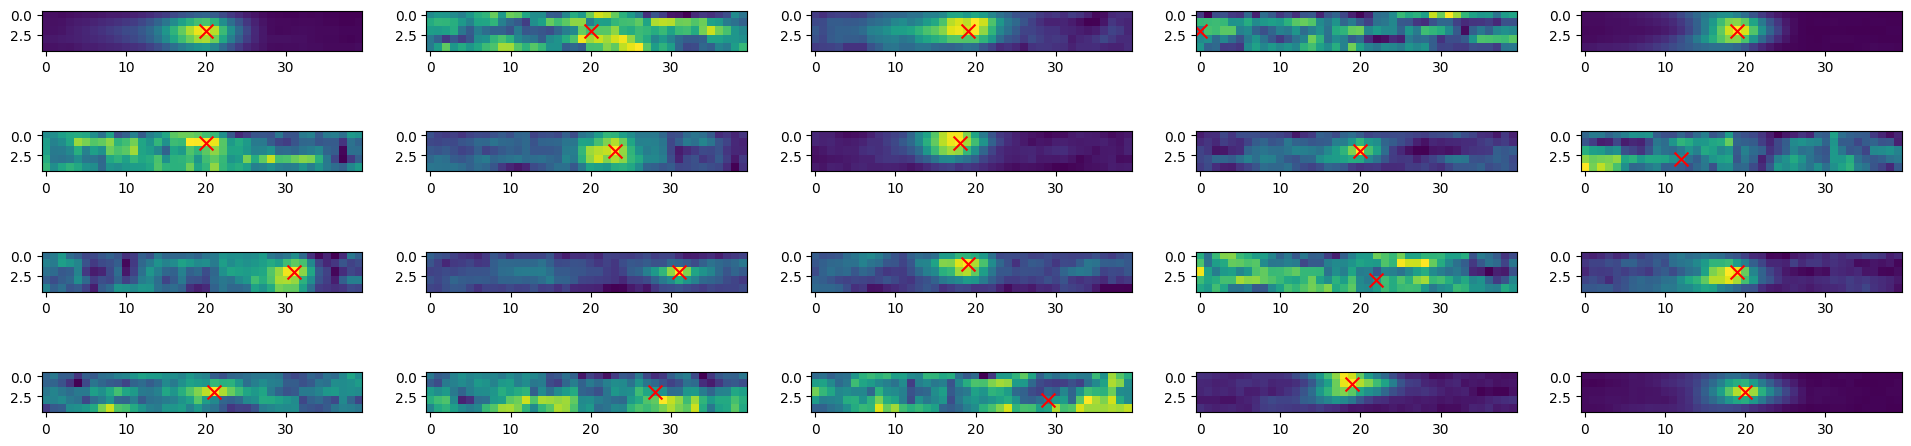

In [135]:
import matplotlib.pyplot as plt
visualize = True
id_ = 7

# Extracting and plotting DDMs
raw_counts = fit_data
raw_counts = np.array(raw_counts)
print(raw_counts.shape)
print('Min:', np.nanmin(raw_counts))
print('Max:', np.nanmax(raw_counts))
print('NaNs:', np.count_nonzero(np.isnan(raw_counts)), '({:.2f}%)'.format(np.count_nonzero(np.isnan(raw_counts))/raw_counts.size*100))
plt.figure(figsize=(24,6))
if visualize:

    for ddm in range(20):

        plt.subplot(4, 5, ddm+1)
        
        plt.imshow(raw_counts[ddm].reshape(40, 5).T,  cmap='viridis')
        sp_center = sp_centers[ddm]
        plt.scatter(sp_center[0], sp_center[1], color='red', marker='x', s=100)
        
    plt.show()

In [ ]:
pd.DataFrame(fit_data).describe()

In [ ]:
# Select a random subset of 2 million samples
num_samples = 5000000
indices = np.random.choice(fit_data.shape[0], size=num_samples, replace=False)
fit_data = fit_data[indices]
labels = labels[indices]
sp_centers = sp_centers[indices]

In [ ]:
fit_data.shape, labels.shape, sp_centers.shape

In [ ]:
# Versione modificata della funzione helper
def extract_ddm_features_row(row, sp_center, extractor):
    """Helper function for parallel processing"""
    return extractor.extract_ddm_features(
        fit_data=row,
        quadrants=True,
        include_peak_features=True,
        sp_center=sp_center  
    )

# Example usage modificato:
features_extractor = DDMFeatureExtractorV2(data_format='40x5',)

# Versione con zip per passare entrambi gli elementi
combined_features = Parallel(n_jobs=8, backend="loky")(
    delayed(extract_ddm_features_row)(row, sp_center, features_extractor)
    for row, sp_center in tqdm(zip(fit_data, sp_centers), desc="Features extraction", total=len(fit_data))
)

In [ ]:
FEATURES = list(combined_features[0].keys())

In [ ]:
# Convert to numpy array if needed
# First convert dict features to arrays
if combined_features:
    feature_names = list(combined_features[0].keys())
    feature_arrays = {name: np.array([f[name] for f in combined_features]) 
                     for name in feature_names}
    combined_features_array = np.column_stack([feature_arrays[name] for name in feature_names])
    print(f"Combined features shape: {combined_features_array.shape}")


In [ ]:
"""flat_features = [row[0] if isinstance(row, list) and len(row) > 0 else row for row in combined_features]

del combined_features

combined_features = np.array([[row[key] for key in FEATURES] for row in flat_features])
del flat_features
combined_features.shape"""

# Check for NaN and infinite values
mask_finite = np.all(np.isfinite(combined_features_array), axis=1) & (np.abs(combined_features_array) < np.finfo(np.float64).max).all(axis=1)

fit_data_with_features_clean = combined_features_array[mask_finite]
labels_clean = labels[mask_finite]
del labels, fit_data

In [ ]:
fit_data_with_features_clean.shape, labels_clean.shape

In [ ]:
pd.DataFrame(fit_data_with_features_clean).describe()

In [ ]:
# Saving features and labels
save = True
if save:
    os.makedirs('processed_data/binary_classification/data_w_features', exist_ok=True)
    pd.DataFrame(fit_data_with_features_clean, columns=FEATURES).to_parquet('processed_data/binary_classification/data_w_features/combined_features_q_peak.parquet', index=False)
    pd.DataFrame(labels_clean).to_parquet('processed_data/binary_classification/data_w_features/labels_binary_q_peak.parquet', index=False)

In [ ]:
fit_data_with_features_df = pd.DataFrame(fit_data_with_features_clean, columns=FEATURES)
labels_clean_df = pd.DataFrame(labels_clean, columns=['0'])
del fit_data_with_features_clean
fit_data_with_features_df.head()